<a href="https://colab.research.google.com/github/Valentinekrafft/Machinelearningproject/blob/main/Machine_learning_Air_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import matplotlib.pyplot as plt
from scipy.stats import norm as normSci
import numpy as np
import pandas as pd
from google.colab import files
import io
from pylab import  *

In [31]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_loc = pd.read_csv(io.BytesIO(uploaded[filename]))

# View the first few rows
df_loc.head()

Saving world_air_quality_with_locations 2.csv to world_air_quality_with_locations 2 (2).csv


,Unnamed: 0,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label,Lat,Long
0,0,CL,Catemu,Santa Margarita,"-32.776573, -70.938144",PM2.5,Chile - SINCA,µg/m³,0.00,2017-06-28T17:00:00+04:00,Chile,-32.776573,-70.938144
1,1,CL,Coyhaique,Coyhaique II,"-45.579045667164, -72.049964505825",SO2,Chile - SINCA,µg/m³,16.63,2023-08-09T11:00:00+04:00,Chile,-45.579046,-72.049965
2,2,CL,Calama,Colegio Pedro Vergara Keller,"-22.44283906304, -68.932546346863",PM10,Chile - SINCA,µg/m³,69.00,2023-08-09T11:00:00+04:00,Chile,-22.442839,-68.932546
3,3,CL,Coquimbo,La Serena,"-29.933006518748, -71.261966365967",PM2.5,Chile - SINCA,µg/m³,21.00,2023-08-09T11:00:00+04:00,Chile,-29.933007,-71.261966
4,4,CL,Talagante,Talagante,"-33.673752071375, -70.953064737434",NO2,Chile - SINCA,µg/m³,134.80,2019-12-05T21:00:00+04:00,Chile,-33.673752,-70.953065


In [33]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_air = pd.read_csv(
    io.BytesIO(uploaded[filename]),
    sep=";",            # séparateur probable du fichier
    encoding="utf-8-sig",  # corrige les erreurs Unicode
    engine="python"     # plus tolérant si certaines lignes sont irrégulières
)

# View the first few rows
df_air.head()

Saving world_air_quality 2.csv to world_air_quality 2 (4).csv


,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label
0,JP,NaN,北九州市小倉北区大門一丁目６－４８,"33.880833, 130.873056",NO,japan-soramame,ppm,0.002,2024-03-10T13:30:00+05:30,Japan
1,JP,NaN,北九州市若松区本町三丁目１３－１,"33.898056, 130.81",NO2,japan-soramame,ppm,0.005,2024-03-10T13:30:00+05:30,Japan
2,JP,NaN,北九州市門司区大里原町１２－１２,"33.895833, 130.935833",NOX,japan-soramame,ppm,0.013,2024-03-10T13:30:00+05:30,Japan
3,JP,NaN,千歳市若草４－１３,"42.786944, 141.605",NO2,japan-soramame,ppm,0.004,2024-03-10T13:30:00+05:30,Japan
4,JP,NaN,千葉市稲毛区宮野木町９９６－９,"35.653889, 140.097778",NOX,japan-soramame,ppm,0.003,2024-03-10T13:30:00+05:30,Japan


In [34]:
# Clean first dataset
df_loc = df_loc.drop(columns=["Unnamed: 0"], errors="ignore")

# Add missing columns to second dataset
if "Lat" not in df_air.columns:
    df_air["Lat"] = np.nan
if "Long" not in df_air.columns:
    df_air["Long"] = np.nan

# Add source label
df_loc["dataset_source"] = "with_locations"
df_air["dataset_source"] = "air_quality"

# Standardize datetime
df_loc["Last Updated"] = pd.to_datetime(df_loc["Last Updated"], errors="coerce")
df_air["Last Updated"] = pd.to_datetime(df_air["Last Updated"], errors="coerce")

# Reorder columns
common_order = [
    "Country Code", "City", "Location", "Coordinates", "Pollutant",
    "Source Name", "Unit", "Value", "Last Updated", "Country Label",
    "Lat", "Long", "dataset_source"
]

df_loc = df_loc[common_order]
df_air = df_air[common_order]

# Combine
df_combined = pd.concat([df_loc, df_air], ignore_index=True)

# Remove exact duplicates
df_combined = df_combined.drop_duplicates()

print(df_combined.shape)
display(df_combined.head())

(97705, 13)


,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label,Lat,Long,dataset_source
0,CL,Catemu,Santa Margarita,"-32.776573, -70.938144",PM2.5,Chile - SINCA,µg/m³,0.00,2017-06-28 17:00:00+04:00,Chile,-32.776573,-70.938144,with_locations
1,CL,Coyhaique,Coyhaique II,"-45.579045667164, -72.049964505825",SO2,Chile - SINCA,µg/m³,16.63,2023-08-09 11:00:00+04:00,Chile,-45.579046,-72.049965,with_locations
2,CL,Calama,Colegio Pedro Vergara Keller,"-22.44283906304, -68.932546346863",PM10,Chile - SINCA,µg/m³,69.00,2023-08-09 11:00:00+04:00,Chile,-22.442839,-68.932546,with_locations
3,CL,Coquimbo,La Serena,"-29.933006518748, -71.261966365967",PM2.5,Chile - SINCA,µg/m³,21.00,2023-08-09 11:00:00+04:00,Chile,-29.933007,-71.261966,with_locations
4,CL,Talagante,Talagante,"-33.673752071375, -70.953064737434",NO2,Chile - SINCA,µg/m³,134.80,2019-12-05 21:00:00+04:00,Chile,-33.673752,-70.953065,with_locations


In [35]:
print(df_combined.info())
print(df_combined.isna().mean().sort_values(ascending=False))
display(df_combined["Pollutant"].value_counts())
display(df_combined["Country Label"].nunique())
display(df_combined["City"].nunique())
display(df_combined["Last Updated"].min(), df_combined["Last Updated"].max())
display(df_combined["Value"].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97705 entries, 0 to 97704
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Code    97705 non-null  object 
 1   City            56953 non-null  object 
 2   Location        97701 non-null  object 
 3   Coordinates     97416 non-null  object 
 4   Pollutant       97705 non-null  object 
 5   Source Name     97705 non-null  object 
 6   Unit            97705 non-null  object 
 7   Value           97705 non-null  float64
 8   Last Updated    97705 non-null  object 
 9   Country Label   97475 non-null  object 
 10  Lat             43231 non-null  float64
 11  Long            43231 non-null  float64
 12  dataset_source  97705 non-null  object 
dtypes: float64(3), object(10)
memory usage: 9.7+ MB
None
Long              0.557535
Lat               0.557535
City              0.417092
Coordinates       0.002958
Country Label     0.002354
Location          0.000

,count
Pollutant,
NO2,17555
PM2.5,17393
O3,16098
PM10,15275
SO2,12666
CO,9644
NO,5883
NOX,2580
BC,235


118

2689

Timestamp('2014-03-13 16:00:00+0400', tz='UTC+04:00')

Timestamp('2024-03-25 14:30:00+0530', tz='UTC+05:30')

,Value
count,9.770500e+04
mean,6.897384e+02
std,3.084968e+04
min,-4.905140e+04
25%,9.000000e-01
50%,1.000000e+01
75%,3.378000e+01
max,3.198676e+06


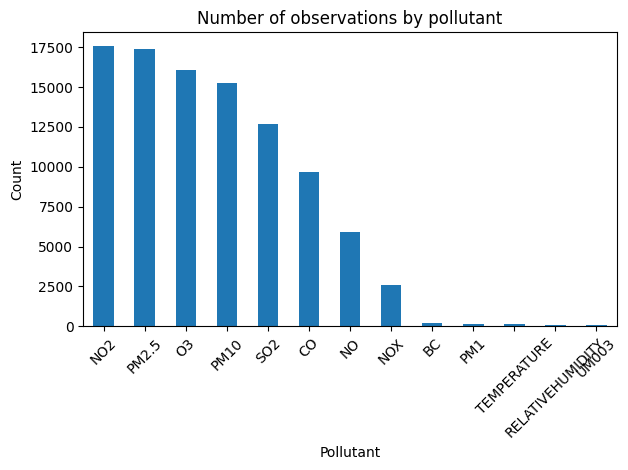

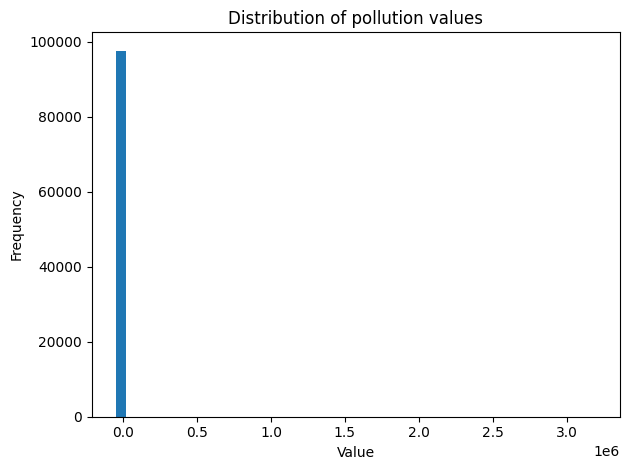

In [36]:
# Pollutant counts
df_combined["Pollutant"].value_counts().plot(kind="bar")
plt.title("Number of observations by pollutant")
plt.xlabel("Pollutant")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribution of pollution values
df_combined["Value"].dropna().plot(kind="hist", bins=50)
plt.title("Distribution of pollution values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [37]:
threshold = df_combined["Value"].quantile(0.99)

df_filtered = df_combined[df_combined["Value"] < threshold]

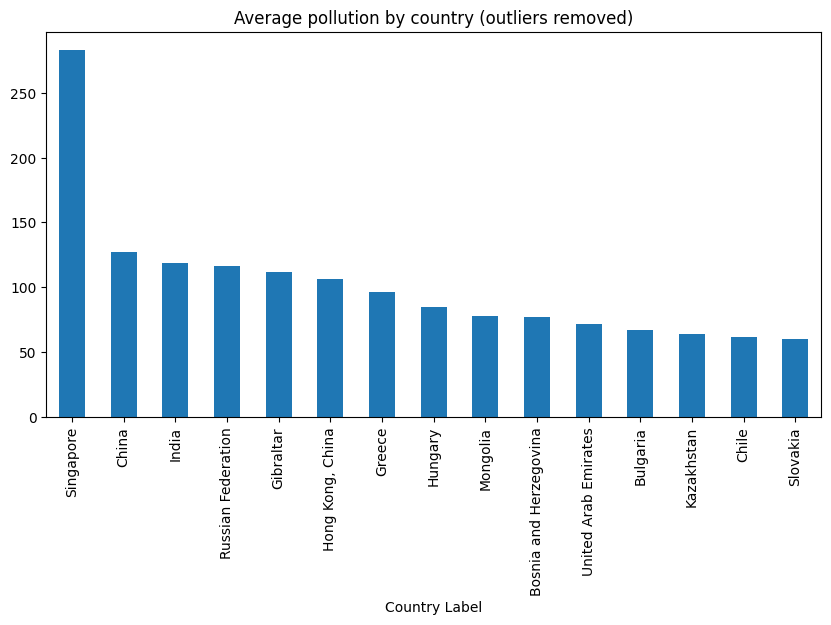

In [38]:
pollution_country = df_filtered.groupby("Country Label")["Value"].mean().sort_values(ascending=False)

pollution_country.head(15).plot(kind="bar", figsize=(10,5))

plt.title("Average pollution by country (outliers removed)")
plt.show()

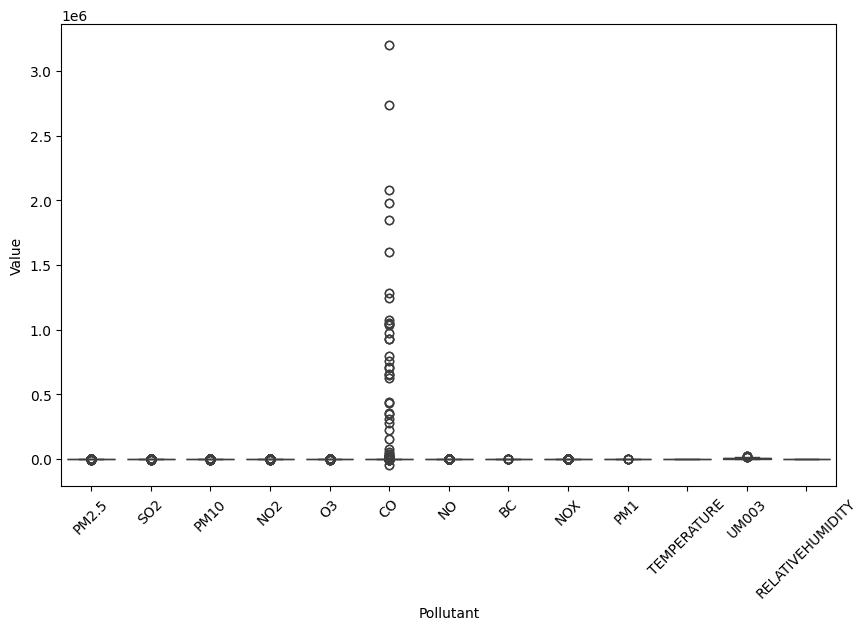

In [39]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df_combined, x="Pollutant", y="Value")
plt.xticks(rotation=45)
plt.show()

In [40]:
pivot = df_pollution.pivot_table(
    values="Value",
    index="Country Label",
    columns="Pollutant",
    aggfunc="mean"
)

pivot.head()

Pollutant,CO,NO2,O3,PM10,PM2.5,SO2
Country Label,,,,,,
Afghanistan,NaN,NaN,NaN,NaN,-431.500000,NaN
Algeria,NaN,NaN,NaN,NaN,53.000000,NaN
Andorra,100.00,4.700000,68.333333,11.0,7.900000,0.20
Antigua and Barbuda,NaN,NaN,NaN,NaN,10.000000,NaN
Argentina,147.88,3.133625,26.000000,15.0,5.799008,5.71


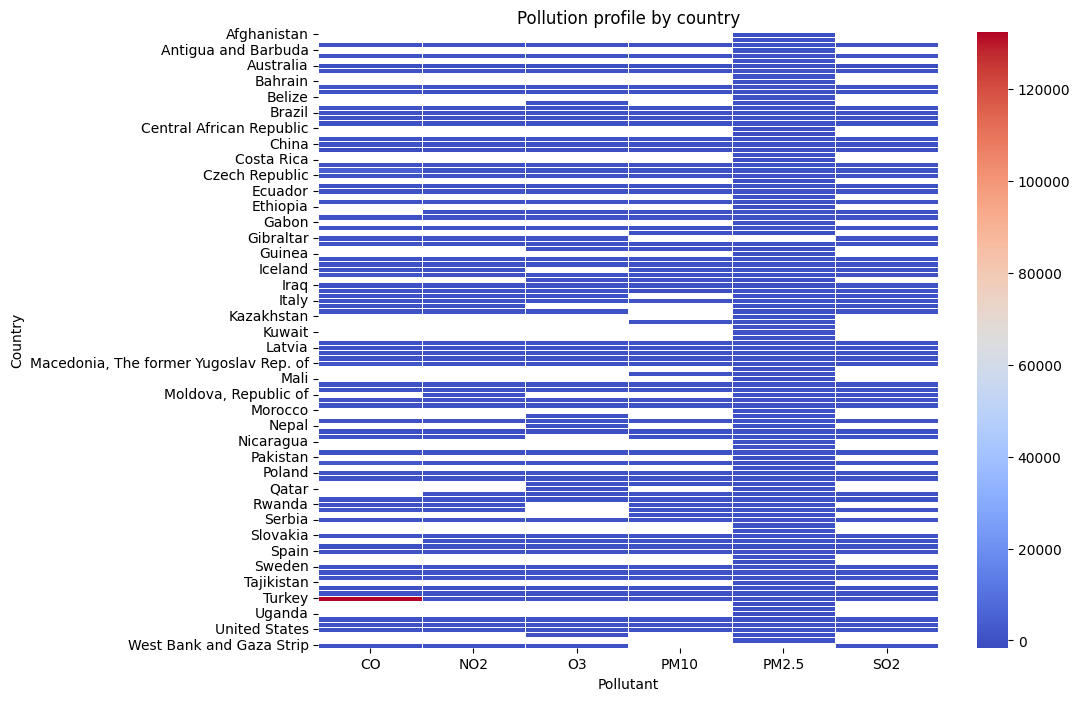

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Pollution profile by country")
plt.ylabel("Country")
plt.xlabel("Pollutant")

plt.show()

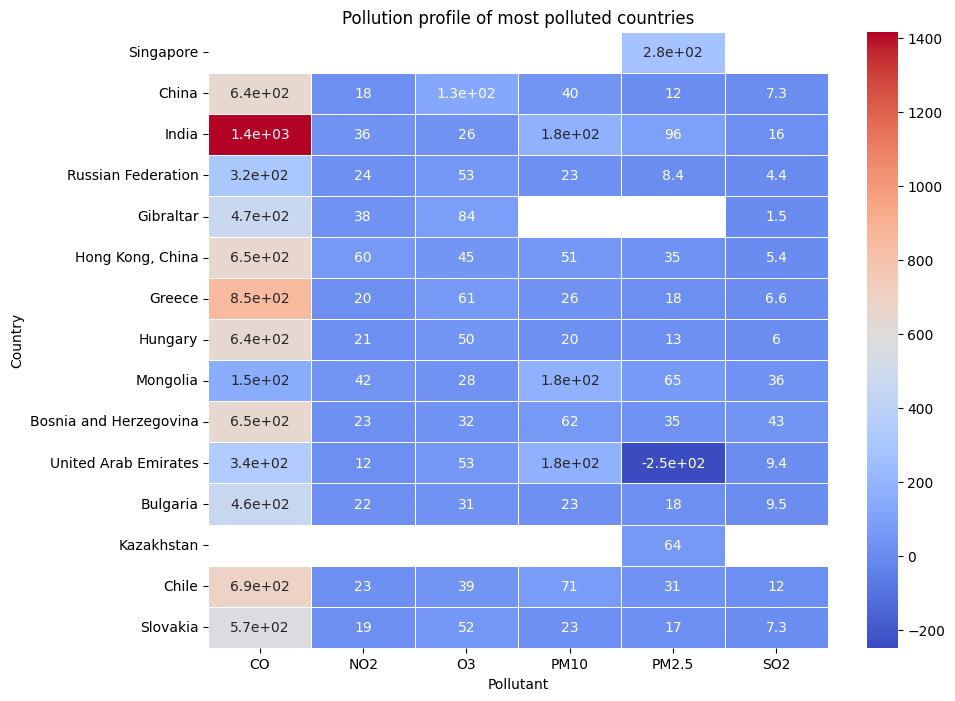

In [44]:
# Top 15 countries with highest average pollution
top_countries = df_filtered.groupby("Country Label")["Value"].mean() \
                           .sort_values(ascending=False) \
                           .head(15) \
                           .index

# Select those countries in the pivot table
pivot_top = pivot.loc[top_countries]

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_top,
    cmap="coolwarm",
    linewidths=0.5,
    annot=True
)

plt.title("Pollution profile of most polluted countries")
plt.xlabel("Pollutant")
plt.ylabel("Country")

plt.show()